#### computer vision is pattern recognition applied to pixels, NLP is pattern recognition applied to words, sentences, and paragraphs.

### Preparing text data
#### Deep learning models, being differentiable functions, can only process numeric tensors: they can’t take raw text as input. Vectorizing text is the process of transforming text into numeric tensors.

1. `standardize` the `text` to make it easier to process, such as by `converting it to lowercase` or `removing punctuation`.
2.  `split` the text into units (called `tokens`), such as characters, words, or groups of words. This is called `tokenization`.
3. `convert` each such token into a `numerical vector`. This will usually involve first indexing all tokens present in the data.


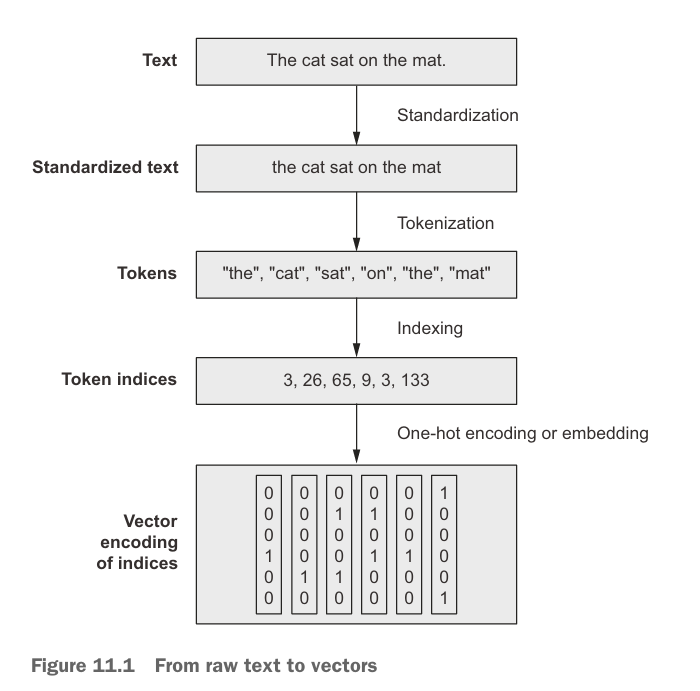

### Text standardization

1. `Goal`: Make text uniform for ML models to understand variations as same.
2. `Problem`: Computers see "i" vs "I", "Mexico" vs "México", "staring" vs "stared" as totally different.
3. `Why it helps:`
   1. `Less Data`: Model needs fewer examples to learn same meaning.
   2. `Better Generalization`: The model will be smarter at understanding new text it hasn't seen before. If it's only seen "mexico" in training, it will still understand "México" after standardization.
   3. `Higher Accuracy`: Reduces "noise," focuses on key info.
4. `Common Techniques:`
   1. `Lowercasing`: Convert all text to lowercase ("Sunset" -> "sunset").
   2. `Punctuation Removal`: Get rid of .,!?; etc.
   3. `Special Character Conversion`: Replace "é" with "e", "æ" with "ae".
   4. `Stemming (Advanced)`: Reduce words to their root form ("staring," "stared" -> "[stare]").
5. `Caution`: Don't remove info critical for your specific task (e.g., keep "?" if detecting questions)

### Text splitting (tokenization)
1. `Goal`: After cleaning text, split it into smaller "units" (tokens) a computer can understand.
2. `Types of Tokens:`
   1. `Word-level`: Each word is a token (e.g., "The cat sat" -> ["The", "cat", "sat"]). `Sub-words`: Can split words further (e.g., "staring" -> "star" + "ing").
   2. `N-gram`: Groups of N consecutive words are tokens (e.g., for N=2: "the cat" -> "the cat").
   3. `Character-level`: Each character is a token (rarely used, special cases only).
3. `Which to Use?` (Depends on your ML model):
   1. `Sequence Models` (care about word order): Use `Word-level` tokenization.
   2. `Bag-of-Words` Models (treat words as a set, order doesn't matter): Use `N-gram` tokenization. N-grams help these models understand some local word connections.

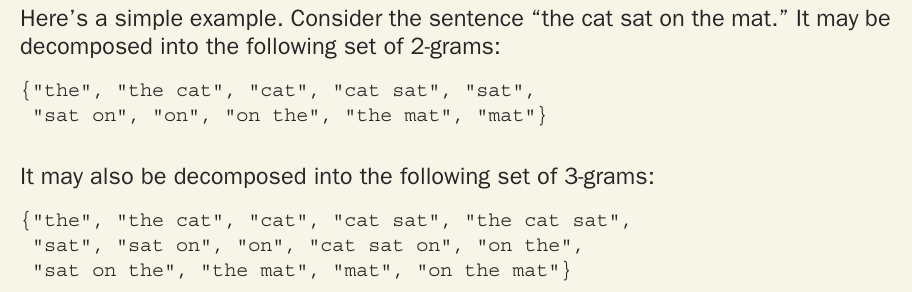

###  Vocabulary indexing
1. `Encoding Text: Giving Words Numbers for Computers`
   1. `Why?` Computers don't understand words directly. We need to turn words (tokens) into numbers.
   2. `How?` (The "Vocabulary" Method - most common):
      1. `Build a "Word Dictionary" (Vocabulary)`: Go through all the words in your training data.
      2. `Assign Unique IDs`: Give each unique word a special number (its "index"). `Example:` "the" = 0, "cat" = 1, "sat" = 2
    3. `Turning IDs into Vectors (for Neural Networks)`:
       1. `One-Hot Encoding`: For each word, create a super-long list of zeros. Put a "1" in the spot that matches the word's unique ID.
       2. Example: If you have 10 words, "cat" (ID 1) becomes `[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]`.
    4. `Managing Your Word Dictionary Size:`
       1. `Limit It!` Only include the top 20,000 or 30,000 most common words.
       2. `Why?` Most words appear very rarely. Including them all makes your data huge and messy without much benefit.
    5. `Handling Unknown Words (OOV - Out Of Vocabulary):`
       1. `Problem`: What if your model sees a word it's never seen before (e.g., "cherimoya")?
       2. `Solution: The "Unknown Word" ID (usually 1)`: Assign a special number (like 1) to all unknown words. So, if "cherimoya" isn't in your dictionary, it gets ID 1. This is often called the `[UNK]` token.
    6. `Two Important Special IDs:`
       1. `ID 0: "Mask" Token`: Means "ignore this, it's not a real word.". `Main Use - [Padding]:` To make all sentences the same length for your computer program, you add these "mask" (0) tokens to the end of shorter sentences. Example: `[5, 7, 124, 4, 89]` and `[8, 34, 21]` becomes: `[[5, 7, 124, 4, 89]`, `[8, 34, 21, 0, 0]]`
       3. `ID 1: "Unknown Word" (OOV) Token`: Means "here was a word we didn't recognize." (Why 1 and not 0? Because 0 is already used for padding!)


In [4]:
import keras
import tensorflow as tf
import re 
import string 
print('TF version: ', tf.__version__)
print('keras version: ', keras.__version__)

TF version:  2.19.0
keras version:  3.9.2


In [10]:
def custom_standardization_fn(string_tensor):
    str_lower = tf.strings.lower(string_tensor) # convert strings to lowercase
    return tf.strings.regex_replace(str_lower, f"[{re.escape(string.punctuation)}]", "") # replace punctuations with empty string

def custom_split_fn(string_tensor):
    return tf.strings.split(string_tensor)

text_vectorization = keras.layers.TextVectorization(
    output_mode="int",
    standardize=custom_standardization_fn,
    split=custom_split_fn,
)

In [11]:
dataset = [
     "I write, erase, rewrite",
     "Erase again, and then",
     "A poppy blooms.",
]

text_vectorization.adapt(dataset)

In [12]:
 text_vectorization.get_vocabulary()

['',
 '[UNK]',
 np.str_('erase'),
 np.str_('write'),
 np.str_('then'),
 np.str_('rewrite'),
 np.str_('poppy'),
 np.str_('i'),
 np.str_('blooms'),
 np.str_('and'),
 np.str_('again'),
 np.str_('a')]

<TextVectorization name=text_vectorization_1, built=False>